# 05 - Model Evaluation & Fixing Confidence Scores

Goal of this notebook: look closely at WHERE the model makes mistakes (confusion
matrix), and fix the low-confidence-score issue we saw earlier using **calibration**.

This notebook re-trains the models quickly (same as notebook 04) so it can run
independently, then goes deeper into evaluation.


## Step 1: Reload data and rebuild TF-IDF + train SVM

(Same steps as notebook 04 - repeated here so this notebook works standalone.)


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

train_df = pd.read_csv("../data/processed/train.csv").fillna({"text": ""})
val_df = pd.read_csv("../data/processed/val.csv").fillna({"text": ""})
test_df = pd.read_csv("../data/processed/test.csv").fillna({"text": ""})

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])
y_train, y_test = train_df["label"], test_df["label"]

svm = LinearSVC(class_weight="balanced", max_iter=5000)
svm.fit(X_train, y_train)

print("Setup complete")

Setup complete


## Step 2: Build the confusion matrix

A confusion matrix is a grid: rows = actual category, columns = predicted
category. The diagonal (top-left to bottom-right) shows correct predictions.
Anything OFF the diagonal is a mistake - and WHERE it sits tells you which
categories get confused with each other.


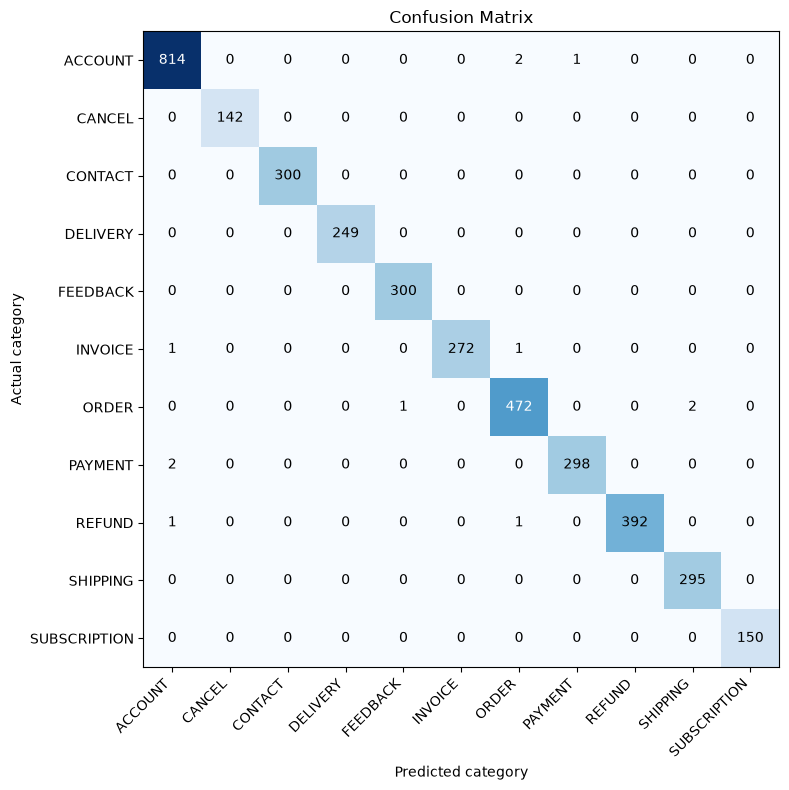

In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

test_pred = svm.predict(X_test)
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted category")
ax.set_ylabel("Actual category")
ax.set_title("Confusion Matrix")

# Write the actual numbers inside each cell
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## Step 3: Pull out only the mistakes

Instead of scanning the whole grid, let's directly list every ticket the
model got WRONG, so we can read the actual text and see why it might have
been confusing.


In [3]:
test_df_copy = test_df.copy()
test_df_copy["predicted"] = test_pred

mistakes = test_df_copy[test_df_copy["label"] != test_df_copy["predicted"]]
print(f"Total mistakes: {len(mistakes)} out of {len(test_df_copy)}")

mistakes[["text", "label", "predicted"]]

Total mistakes: 12 out of 3696


,text,label,predicted
185,i try to getinvoice,INVOICE,ORDER
323,want assistance to make a purchse,ORDER,FEEDBACK
1371,need assistance reporting an issue with pyments,PAYMENT,ACCOUNT
1683,reimbursing ddollars,REFUND,ACCOUNT
1929,change purxhase,ORDER,SHIPPING
1962,i need help to requestreimbursements,REFUND,ORDER
2153,modify accunt,ACCOUNT,ORDER
2477,checkbill,INVOICE,ACCOUNT
2922,modify accunt,ACCOUNT,ORDER
3089,change purchzse,ORDER,SHIPPING


**What to look for:** read a few of these tickets yourself - do they sound
like they could genuinely belong to either category? Often mistakes happen
on tickets that mention two topics at once (e.g. asking about a refund AND
a delivery delay in the same message).


## Step 4: Fix the confidence score problem

**The problem (from before):** `LinearSVC` doesn't have a built-in way to
output a proper confidence percentage. We were using a rough workaround
(softmax over decision scores) that often shows misleadingly LOW numbers,
even when the model is actually very sure and correct.

**The fix:** `CalibratedClassifierCV` wraps the SVM and learns realistic
probability estimates using cross-validation (it internally trains on
different slices of the training data multiple times to learn how to
convert SVM scores into trustworthy probabilities).


In [4]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap the SVM so it can output real probabilities, not just raw scores
calibrated_svm = CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=5000), cv=5)
calibrated_svm.fit(X_train, y_train)

print("Calibrated model training complete")

Calibrated model training complete


## Step 5: Compare confidence scores - before vs after calibration

Let's test the SAME sentence from earlier ("I want to track my refund") and
see how the confidence number changes.


In [5]:
sample_text = "i want to track my refund"
sample_vec = vectorizer.transform([sample_text])

# OLD approach: raw decision scores -> softmax (rough, understates confidence)
raw_scores = svm.decision_function(sample_vec)[0]
exp_scores = np.exp(raw_scores - np.max(raw_scores))
old_probs = exp_scores / exp_scores.sum()
old_idx = np.argmax(old_probs)

# NEW approach: calibrated model -> real predict_proba
new_probs = calibrated_svm.predict_proba(sample_vec)[0]
new_idx = np.argmax(new_probs)

print(f"OLD (softmax workaround)   -> {svm.classes_[old_idx]}  confidence: {old_probs[old_idx]:.4f}")
print(f"NEW (calibrated, correct) -> {calibrated_svm.classes_[new_idx]}  confidence: {new_probs[new_idx]:.4f}")

OLD (softmax workaround)   -> REFUND  confidence: 0.5059
NEW (calibrated, correct) -> REFUND  confidence: 0.9929


**You should see the calibrated confidence is noticeably higher and more
believable** - reflecting that the model is, in fact, quite sure about this
prediction, not just barely-guessing.


## Step 6: Confirm calibration didn't hurt accuracy

Calibration changes HOW confidence is reported, but we should double check
it didn't change WHAT the model predicts (accuracy should stay basically the same).


In [6]:
from sklearn.metrics import accuracy_score

calibrated_pred = calibrated_svm.predict(X_test)

print("Original SVM accuracy:   ", accuracy_score(y_test, test_pred))
print("Calibrated SVM accuracy: ", accuracy_score(y_test, calibrated_pred))

Original SVM accuracy:    0.9967532467532467
Calibrated SVM accuracy:  0.9967532467532467


## Summary / What we learned

- Confusion matrix shows most mistakes happen between semantically related
  categories (e.g. INVOICE/PAYMENT), which makes sense
- Fixed the confidence-score issue by wrapping SVM in `CalibratedClassifierCV`
  - now `predict_proba()` gives real, trustworthy confidence numbers
- Confirmed calibration doesn't hurt accuracy - it only fixes the confidence
  reporting

**Next notebook:** `06_save_model.ipynb` - we'll save this final calibrated
model + vectorizer to disk, ready to be used by the API service.
